In [16]:
# libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import json


import seaborn as sns
from matplotlib.lines import Line2D


from tqdm import tqdm
from scipy.stats import gaussian_kde


from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance



In [17]:
labels = [# 'human',
          'gpt_5.1',
          'gpt_5.4',
          'gpt_5.4_mini',
          'gpt_5.4_nano',
          'Llama_3.3_70B_Instruct',
          'Gemma_4_31B',
          'Qwen3.5_27B',
          'Qwen3.5_9B',
          ]

In [18]:
human_svo_values = np.array(
    [7.81529355, 7.81529355, 25.71897248, 37.48241143,
     12.17591252, 34.87532834, 22.03622694, 37.92362182,
     7.98011375, 32.33294007, 34.87532834, 32.28886743,
     34.87532834, 20.90556934, 21.18834575, -8.3886889,
     -2.17474411, 34.87532834, -7.81529355, 37.48241143,
     13.1092082, 37.48241143, 9.35034363, -2.69141002,
     26.87253899, 7.29205896, 6.94098343, -5.22065123,
     37.48241143, 25.06044233, 34.87532834, 13.90528191,
     29.3416547, 0., 35.51043301, -2.79270237,
     7.81529355, 34.87532834, 34.87532834, 37.48241143,
     37.48241143, 22.76500911, 27.92358972, 28.73979529,
     45., 22.44774864, 37.48241143, 26.87253899,
     7.81529355, 36.11934085, 8.51942216, 30.84380741,
     7.81529355, 34.87532834, -5.82180375, 32.15810372,
     4.47082084, 7.81529355, 28.14160123, 7.81529355,
     34.87532834, 33.69006753, 23.83874018, 37.48241143,
     6.98561083, 26.87253899, 43.29527168, 34.24903301,
     31.35404872, 37.48241143, 37.48241143, 1.46880071,
     34.87532834, 7.81529355, -16.26020471, 4.18491613,
     25.01689348, 22.56700908, 38.43730149, 32.56286546,
     26.13641244, 29.38415713, 37.48241143, 34.87532834,
     34.87532834, 34.87532834, 31.85513238, 31.49768024,
     34.87532834, 29.90447916, 37.01361585, 18.80579011,
     41.6101342, 22.95658232, 37.48241143, 34.02949353,
     34.87532834, 4.10387547, 21.03751103, 34.87532834,
     37.85341956, 7.81529355, 16.77466645, 34.87532834,
     7.81529355, 31.85513238, 34.87532834, 24.92457036,
     30.84380741, 37.48241143, 30.08235254, 34.87532834,
     7.81529355, -15.29654731, 7.81529355, 20.46586306,
     37.48241143, 45., -7.39959466, 28.27912656,
     15.55198537, 18.80579011, -7.81529355, 27.84757826,
     34.87532834, 9.8530802, 34.87532834, 23.81256578,
     27.76994729, 12.76766314, 19.81715252, -3.81407483,
     15.35013649, 19.90374954, 29.53878226, 16.24107104,
     26.0441948, 37.48241143, 30.59778421, 7.81529355,
     14.62087399, 3.26333132, 7.81529355, 33.26142879,
     38.98249697, 37.48241143, 7.81529355, 37.48241143,
     -7.81529355, 4.15128527, -7.81529355, 45.,
     37.48241143, 31.83528243, 45., 37.48241143,
     36.49716084, 22.91510629, -7.81529355, -7.81529355,
     16.6501055, 37.0928373, 28.44292862, 37.48241143,
     37.48241143, 41.91906411, 34.87532834, 34.87532834,
     4.15128527, 31.85513238, 54.13017648, 37.48241143,
     20.96982555, 11.96847565, 34.87532834, 27.18111109,
     20.00328109, 34.16695361, -9.50324776, 37.48241143,
     23.48877487, 7.09367293, 30.46554492, -7.09669417,
     3.55926682, 45., 32.15810372, 30.59778421,
     7.81529355, 37.48241143, 34.87532834, 7.81529355,
     37.48241143, 35.20617264, 22.68878526, 7.81529355,
     45., 7.81529355, 40.40945681, 20.22485943,
     22.93210044, 31.62324717, 31.73088462, 34.87532834,
     30.53582921, 37.48241143, 37.48241143, 34.87532834,
     18.43494882, 28.05467662, 37.0928373, 26.87253899,
     45., 16.26020471, 19.51274517, 30.84380741,
     23.86017519, 29.53878226, 26.95658799, 48.0127875,
     28.61045967, 7.68844777, 13.04563706, 37.48241143,
     34.87532834, 15.60394715, 34.87532834, 37.48241143,
     39.11755441, 34.87532834, 39.99416745, 21.61026498,
     20.79716228, 34.87532834, 27.31327442, 7.81529355,
     27.79342741, 39.43679118, 15.21454096, 44.83098639,
     13.20792846, 21.49478362, 41.59355625, 40.07289005,
     37.48241143, 31.01243603, 37.48241143, 33.09394798,
     37.48241143, 23.83874018, 13.81502534, 37.48241143,
     33.82208522, 34.87532834, 24.19625259, 34.87532834,
     37.48241143, 37.916714, 21.03751103, 34.87532834,
     7.81529355, 6.00900596, 34.87532834, 22.36366602,
     29.37261626, 37.48241143, 52.9071627, 37.48241143,
     34.87532834, 32.427555, 43.02506599, 29.59489269,
     40.548826, 29.43256845, 34.87532834, -7.81529355,
     7.81529355, 32.3545796, 43.29527168, 14.62087399,
     7.81529355, 23.82094831, 34.87532834, 34.87532834,
     23.74949449, 22.46321249, 34.87532834, 45.,
     39.86955295, 5.82180375, 24.19625259, -7.81529355,
     37.48241143, 37.48241143, 45., 37.01361585,
     32.76388849, 37.48241143, 9.51096038, 12.17591252,
     34.87532834, 52.9071627, 26.32829311, 37.48241143,
     34.87532834, 7.81529355, 7.81529355, 7.81529355,
     20.33260877, 45.84005387, 27.45674228, 26.87253899,
     34.87532834, 34.87532834, 31.85513238, 34.87532834,
     34.87532834, 34.87532834, 34.87532834, 22.5205656,
     37.48241143, 20.7640684, 10.17551084, 26.23193993,
     16.26020471],
    dtype=float)


In [19]:
human_svo_values_rounded = np.round(human_svo_values).astype(int)
# print(human_svo_values_rounded.min(), human_svo_values_rounded.max())

delta =  0
support = np.arange(human_svo_values_rounded.min() - delta, human_svo_values_rounded.max() + delta)
# print(support)

counts = dict(zip(*np.unique(human_svo_values_rounded, return_counts=True)))
svo_distribution_human = {int(k): float(counts.get(k, 0)/len(human_svo_values_rounded)) for k in support}

print(svo_distribution_human)

{-16: 0.003076923076923077, -15: 0.003076923076923077, -14: 0.0, -13: 0.0, -12: 0.0, -11: 0.0, -10: 0.003076923076923077, -9: 0.0, -8: 0.027692307692307693, -7: 0.006153846153846154, -6: 0.003076923076923077, -5: 0.003076923076923077, -4: 0.003076923076923077, -3: 0.006153846153846154, -2: 0.003076923076923077, -1: 0.0, 0: 0.003076923076923077, 1: 0.003076923076923077, 2: 0.0, 3: 0.003076923076923077, 4: 0.018461538461538463, 5: 0.0, 6: 0.006153846153846154, 7: 0.012307692307692308, 8: 0.08615384615384615, 9: 0.006153846153846154, 10: 0.009230769230769232, 11: 0.0, 12: 0.009230769230769232, 13: 0.012307692307692308, 14: 0.006153846153846154, 15: 0.012307692307692308, 16: 0.015384615384615385, 17: 0.006153846153846154, 18: 0.003076923076923077, 19: 0.006153846153846154, 20: 0.021538461538461538, 21: 0.024615384615384615, 22: 0.015384615384615385, 23: 0.024615384615384615, 24: 0.024615384615384615, 25: 0.009230769230769232, 26: 0.015384615384615385, 27: 0.027692307692307693, 28: 0.024615

In [20]:
# parameters of file
v = 1
n = 3
nb_samples = 3

In [21]:
project_dir = os.path.abspath("..")
svo_values = pd.read_csv(os.path.join(project_dir, 'data', 'svo_values.csv'))


In [22]:
def get_items_avg(model: str, 
                  v: int, # version of instruction prompt
                  n: int, # n parameter in completion 
                  blinded: bool, # blinding in system prompt
                  inv_flag: bool,
                  tol: float = 1.0e-3,
                  ):
    if blinded:
        blind = 'blinded'
    else:
        blind = 'unblinded'
    if inv_flag:
        inv = '-inv'
    else:
        inv = ''
        
    file_name = f'{model}-svo-v{v}-n{n}-{blind}{inv}.json'
    
    project_dir = os.path.abspath("..")
    path_to_file = os.path.join(project_dir, 'output', file_name)
    with open(path_to_file, encoding='utf-8') as f:
         data = json.load(f)
        
    items_avg =np.zeros((6,9), dtype = float)
    for i in range(6):
        samples_avg = np.zeros((n, 9), dtype = float) 
        for j in range(n):
            tmp_df = pd.DataFrame(data[f'item{i+1}'][j]).T
            # tmp_df : columns are choices 1:9, rows are samples 0:n-1
            for k in range(len(tmp_df)):
                nb_nan = tmp_df.iloc[k,:].isna().sum()
                if nb_nan > 0:
                    row_sum = tmp_df.iloc[k,:].sum()
                    if 1. <= row_sum < 1.+tol:
                        # print(f'the sum of non nans is between 1 and {1+tol}')
                        tmp_df.iloc[k,:] = tmp_df.iloc[k,:].fillna(0.)
                    elif 0. <= row_sum < 1.:
                         # print('the sum of non nans is between 0 and 1')
                         tmp_df.iloc[k,:] = tmp_df.iloc[k,:].fillna((1-row_sum)/nb_nan)
                    else:
                        print(f'the sum of non nans is less than 0. and more than {1+tol}')
                        
                # maybe unnecessary but clipping and re-normalizing just to be sure
                tmp_df.iloc[k,:] = np.clip(tmp_df.iloc[k,:], 0., 1.)
                tmp_df.iloc[k,:] = tmp_df.iloc[k,:].astype(float)/tmp_df.iloc[k,:].sum()
                
            assert np.allclose(tmp_df.sum(axis=1), 1.)
            samples_avg[j,:] = tmp_df.mean(axis=0)
        
        items_avg[i,:] = samples_avg.mean(axis=0)
        if inv_flag:
            items_avg[i,:] = np.flip(items_avg[i,:])
            
        
    return items_avg

In [23]:
def compute_svo(config, svo_values=svo_values):
    l = len(config)
    assert l == 6
    
    you = np.empty(l)
    other = np.empty(l)
    
    for item, choice in enumerate(config):
        row = svo_values[(svo_values['question_idx']==item+1) & (svo_values['value']==choice)].copy()
        you[item] = row['self'].values[0]
        other[item] = row['other'].values[0]
    avg_you = np.mean(you)
    avg_other = np.mean(other)
    
    return np.rad2deg(np.arctan((avg_other - 50) / (avg_you - 50)))
    
from itertools import product



def compute_svo_distribution(table: np.ndarray,
                             support: np.ndarray,
                             tol : float =1.0e-10,
                             ):
    choices = np.arange(9)
    
    prob = {int(k): 0. for k in support}
    for config in product(*6*[choices]):
        config_prob = 1.
        for i in range(6):
            config_prob *= table[i, config[i]]
        
        if config_prob > tol:    
            svo_value = int(np.round(compute_svo(config)))
            assert svo_value in support
            prob[svo_value] += config_prob

    return prob
        
    

In [24]:
support = np.arange(-30, 70)

In [25]:
project_dir = os.path.abspath("..")

blinded_flags = [True, False]
inv_flags = [False, True]
inv_labels = {False: 'standard', True: 'inverted'}



# avg_dict = {}
# std_dict = {}
# for z, label in enumerate(labels):
#     avg_dict[label] = np.zeros((2, 2), dtype = float)
#     std_dict[label] = np.zeros((2, 2), dtype = float)
#     for i, blinded in enumerate(blinded_flags):
#         for j, inv_flag in enumerate(inv_flags):
#             
#             items_avg = get_items_avg(label, v, n, blinded, inv_flag)
#             
#             assert np.allclose(items_avg.sum(axis=1), 1.) and (items_avg >=0).all()
#             
#             svo_distribution = compute_svo_distribution(table=items_avg, support=support , tol=1e-10)
#             
#             assert np.isclose(np.sum(list(svo_distribution.values())), 1., rtol=1e-5)
#             
#             avg = sum(k * p for k, p in svo_distribution.items())
#             std = np.sqrt(sum((x - avg)**2 * p for x, p in svo_distribution.items()))
#             
#             avg_dict[label][i,j] = avg
#             std_dict[label][i,j] = std
            
avg_dict = {'gpt_5.1': np.array([[26.04693993, 27.53142288],
        [33.47856062, 24.38871949]]),
 'gpt_5.4': np.array([[11.07602293, 25.2661871 ],
        [33.89118178, 31.90840582]]),
 'gpt_5.4_mini': np.array([[30.03239966, 29.63320926],
        [30.23688557, 31.5175665 ]]),
 'gpt_5.4_nano': np.array([[28.94623147, 10.74125653],
        [33.18357602, 18.35212119]]),
 'Llama_3.3_70B_Instruct': np.array([[28.26994485, 26.84851838],
        [33.40208645, 26.07858051]]),
 'Gemma_4_31B': np.array([[23.98823162,  8.66835768],
        [34.99648445, 15.82240786]]),
 'Qwen3.5_27B': np.array([[32.82642524, 27.06627615],
        [33.54206498, 26.19892502]]),
 'Qwen3.5_9B': np.array([[23.36679376, 23.452556  ],
        [22.5893829 , 22.08053172]])}
            
            
std_dict = {'gpt_5.1': np.array([[9.08227492, 5.99129889],
        [4.08476883, 5.29732241]]),
 'gpt_5.4': np.array([[3.91310423, 5.54894049],
        [1.6575457 , 4.85145389]]),
 'gpt_5.4_mini': np.array([[6.14432513, 8.78534731],
        [5.79186911, 6.77713632]]),
 'gpt_5.4_nano': np.array([[8.57262087, 9.45687278],
        [6.13021516, 9.87318539]]),
 'Llama_3.3_70B_Instruct': np.array([[0.9146371 , 1.29631824],
        [1.79397182, 1.38551525]]),
 'Gemma_4_31B': np.array([[1.09381059, 2.26964184],
        [0.27746137, 3.75247765]]),
 'Qwen3.5_27B': np.array([[ 8.31613576, 10.06199257],
        [ 8.35797888, 10.21257097]]),
 'Qwen3.5_9B': np.array([[8.48693652, 7.89198572],
        [7.64946048, 7.2432328 ]])}



In [26]:
avg_dict


{'gpt_5.1': array([[26.04693993, 27.53142288],
        [33.47856062, 24.38871949]]),
 'gpt_5.4': array([[11.07602293, 25.2661871 ],
        [33.89118178, 31.90840582]]),
 'gpt_5.4_mini': array([[30.03239966, 29.63320926],
        [30.23688557, 31.5175665 ]]),
 'gpt_5.4_nano': array([[28.94623147, 10.74125653],
        [33.18357602, 18.35212119]]),
 'Llama_3.3_70B_Instruct': array([[28.26994485, 26.84851838],
        [33.40208645, 26.07858051]]),
 'Gemma_4_31B': array([[23.98823162,  8.66835768],
        [34.99648445, 15.82240786]]),
 'Qwen3.5_27B': array([[32.82642524, 27.06627615],
        [33.54206498, 26.19892502]]),
 'Qwen3.5_9B': array([[23.36679376, 23.452556  ],
        [22.5893829 , 22.08053172]])}

In [27]:
std_dict

{'gpt_5.1': array([[9.08227492, 5.99129889],
        [4.08476883, 5.29732241]]),
 'gpt_5.4': array([[3.91310423, 5.54894049],
        [1.6575457 , 4.85145389]]),
 'gpt_5.4_mini': array([[6.14432513, 8.78534731],
        [5.79186911, 6.77713632]]),
 'gpt_5.4_nano': array([[8.57262087, 9.45687278],
        [6.13021516, 9.87318539]]),
 'Llama_3.3_70B_Instruct': array([[0.9146371 , 1.29631824],
        [1.79397182, 1.38551525]]),
 'Gemma_4_31B': array([[1.09381059, 2.26964184],
        [0.27746137, 3.75247765]]),
 'Qwen3.5_27B': array([[ 8.31613576, 10.06199257],
        [ 8.35797888, 10.21257097]]),
 'Qwen3.5_9B': array([[8.48693652, 7.89198572],
        [7.64946048, 7.2432328 ]])}

8 0.08615384615384615
35 0.15076923076923077
37 0.13846153846153847


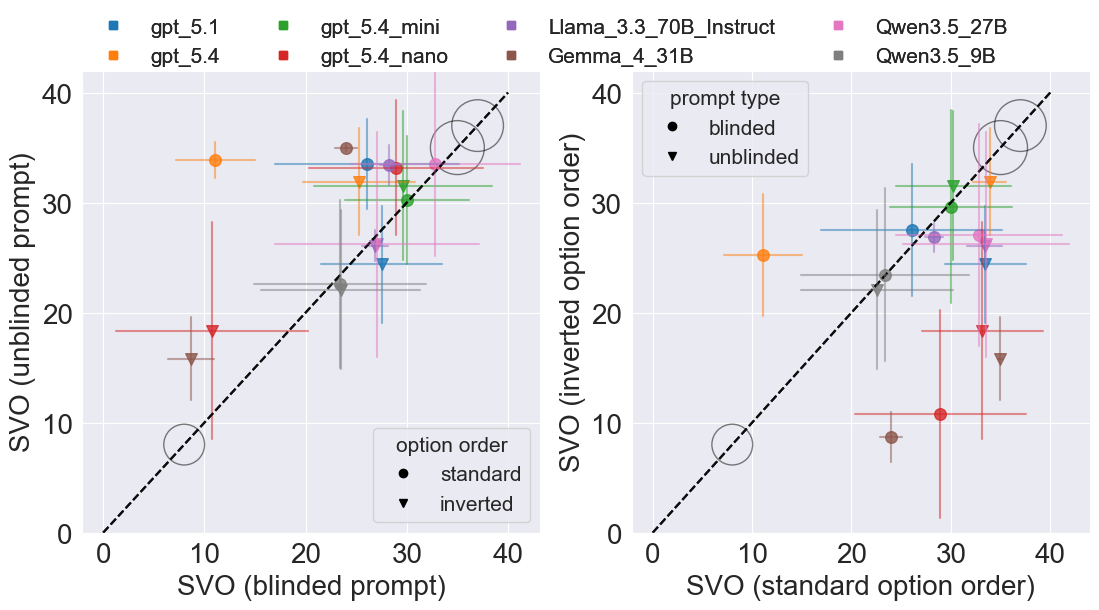

In [41]:
from matplotlib import cm

markers = ['o', 'v']

colors = cm.tab10(range(len(labels)))



fig, ax = plt.subplots(1, 2, figsize=(13, 6),)

for k, val in svo_distribution_human.items():
    if val >= 0.05:
        print(k, val)
        for idx in range(2):
            ax[idx].scatter(k, k, s=10000*val, facecolors='none', edgecolors='black', alpha=0.5)
            ax[idx].set_ylim(0, 42)

for l, label in enumerate(labels):
    values = avg_dict[label]
    stds = std_dict[label]
    
    # ax[0].plot(values[0, :], values[1, :], linestyle=':', color= colors[l],)
    ax[0].scatter(values[0, 0], values[1, 0], marker=markers[0], color= colors[l], label=label, s = 70, alpha=0.8)
    ax[0].plot(np.array([values[0, 0]-stds[0,0], values[0, 0]+stds[0,0]]), np.array(2*[values[1, 0]]), color= colors[l], alpha=0.5)
    ax[0].plot(np.array(2*[values[0, 0]]), np.array([values[1, 0]-stds[1, 0], values[1, 0]+stds[1, 0]]), color= colors[l], alpha=0.5)
    
    ax[0].scatter(values[0, 1], values[1, 1], marker=markers[1], color= colors[l], label=label, s = 70, alpha=0.8)
    ax[0].plot(np.array([values[0, 1]-stds[0, 1], values[0, 1]+stds[0, 1]]), np.array(2*[values[1, 1]]), color= colors[l], alpha=0.5)
    ax[0].plot(np.array(2*[values[0, 1]]), np.array([values[1, 1]-stds[1, 1], values[1, 1]+stds[1, 1]]), color= colors[l], alpha=0.5)
    
    ax[0].plot(np.linspace(0, 40),np.linspace(0, 40), linestyle='--', alpha=0.3, color='black')
    ax[0].set_xlabel('SVO (blinded prompt)', fontsize=20,)
    ax[0].set_ylabel('SVO (unblinded prompt)', fontsize=20,)
    ax[0].tick_params(axis="both", which="major", labelsize=20)
    
    # ax[1].plot(values[:, 0], values[:, 1], linestyle=':', color= colors[l],)
    ax[1].scatter(values[0, 0], values[0, 1], marker=markers[0], color= colors[l], label=label, s = 70, alpha=0.8)
    ax[1].plot(np.array([values[0, 0]-stds[0,0], values[0, 0]+stds[0,0]]), np.array(2*[values[0, 1]]), color= colors[l], alpha=0.5)
    ax[1].plot(np.array(2*[values[0, 0]]), np.array([values[0, 1]-stds[0, 1], values[0, 1]+stds[0, 1]]), color= colors[l], alpha=0.5)
    
    ax[1].scatter(values[1, 0], values[1, 1], marker=markers[1], color= colors[l], label=label, s = 70, alpha=0.8)
    ax[1].plot(np.array([values[1, 0]-stds[1, 0], values[1, 0]+stds[1, 0]]), np.array(2*[values[1, 1]]), color= colors[l], alpha=0.5)
    ax[1].plot(np.array(2*[values[1, 0]]), np.array([values[1, 1]-stds[1, 1], values[1, 1]+stds[1, 1]]), color= colors[l], alpha=0.5)
    
    ax[1].plot(np.linspace(0, 40),np.linspace(0, 40), linestyle='--', alpha=0.3, color='black')
    ax[1].set_xlabel('SVO (standard option order)', fontsize=20,)
    ax[1].set_ylabel('SVO (inverted option order)', fontsize=20,)
    ax[1].tick_params(axis="both", which="major", labelsize=20)


# Legend 1: colors / labels
color_handles = [
    Line2D(
        [0], [0],
        marker="s",
        linestyle="none",
        markerfacecolor=color,
        markeredgecolor=color,
        label=label
    )
    for label, color in zip(labels, colors)
]

legend_colors = fig.legend(
    handles=color_handles,
    # title="LLM",
    loc="upper center",
    ncol=len(labels)//2,
    fontsize=15,
    frameon=False,
)

# Keep the first legend when adding the second
fig.add_artist(legend_colors)

# Legend 2: markers
marker_legend_titles = ['option order', 'prompt type']
for k, marker_labels in enumerate([['standard', 'inverted'], ['blinded', 'unblinded']]):
    marker_handles = [
        Line2D(
            [0], [0],
            marker=marker,
            linestyle="none",
            color="black",
            label=marker_label
        )
        for marker, marker_label in zip(markers, marker_labels)
    ]

    ax[k].legend(
        handles=marker_handles,
        title=marker_legend_titles[k],
        # loc="upper right"
        fontsize=15,
        title_fontsize=15,
    )




name = f'res4-v{v}-n{n}.pdf'
path_to_fig = os.path.join(project_dir, 'figures', name)
plt.savefig(path_to_fig, format='pdf', bbox_inches='tight')


plt.show()